In [18]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split,
    GroupKFold,
    cross_validate,
    LeaveOneGroupOut,
    GridSearchCV
)
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [3]:
x,y = load_breast_cancer(return_X_y = True,as_frame = True)
y = y.map({1:0,0:1})
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
#divide the patients into 10 groups
patient_list = [p for p in range(10)]
print(patient_list)
np.random.seed(1) #generates exact same sequence of random numbers
x['patient'] = np.random.choice(patient_list,size = len(x)) #assign random values from patient_list to each of rows in the data under patient column
print(x['patient'])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
0      5
1      8
2      9
3      5
4      0
      ..
564    1
565    1
566    4
567    6
568    5
Name: patient, Length: 569, dtype: int64


<Axes: xlabel='patient'>

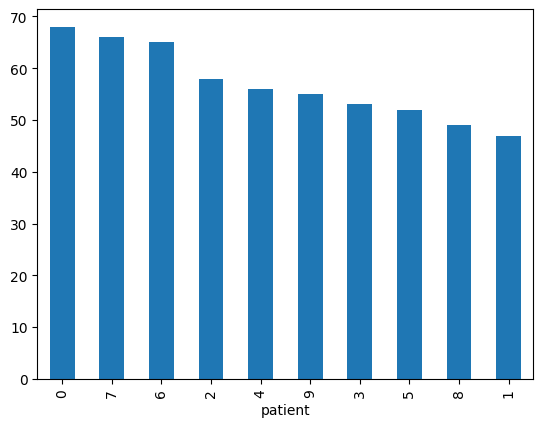

In [15]:
x.columns
x['patient'].unique()
x['patient'].value_counts().plot.bar() #count the values for patient list and group them into the bar chart

In [ ]:
# USE 7TH GROUP FOR TESTING, remove from training, but for y 7th group is still there
x_train = x[x['patient']!=7]
y_train = y.iloc[x_train.index] 
x_test = x[x['patient']==7]
y_test = y.iloc[x_test.index] 

In [19]:
#cross validattion
logit = LogisticRegression(penalty = 'l2',solver = 'liblinear',random_state = 4,C = 10,max_iter = 10000)
gkf = GroupKFold(n_splits = 5)
clf = cross_validate(logit,
       x_train.drop('patient',axis = 1),
       y_train,
       cv = gkf.split(x_train.drop('patient',axis = 1),y_train,groups = x_train['patient']),
       scoring = 'accuracy'
       )

In [20]:
print(clf)

{'fit_time': array([0.01894927, 0.01595712, 0.01495981, 0.01595736, 0.01495719]), 'score_time': array([0.00698137, 0.00498724, 0.00598693, 0.00498676, 0.01296592]), 'test_score': array([0.94117647, 0.98214286, 0.94392523, 0.94444444, 0.97222222])}


check what the value clf indicate